In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

visa = pd.read_csv('/Users/pranay/Naresh IT/Data Files/Visadataset.csv')

cat = visa.select_dtypes(include='object').columns
num = visa.select_dtypes(exclude='object').columns

### Bi-Variate & Multi-Variate Analysis

- Two or more columns analysis

**continent vs case_status**

In [9]:
visa['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [11]:
visa['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- total applicants are 25480

- in that how many got visa : 17018

    - those who got visa applicants all continents are included

- from asia 16861 applied for visa

    - x member got visa : certified 

    - y member got visa : Denied

- we want x and y count

- out of 16861 asia applicants how many got visa and how many are not 

In [ ]:
# step 1 : con1 = apply asia condition on continent
# step 2 : con2 = apply certified condition on case_status
# step 3 : condition = 

In [22]:
asia_df = ( visa[visa['continent'] == 'Asia']['case_status'].value_counts() )

asia_df

case_status
Certified    11012
Denied        5849
Name: count, dtype: int64

In [30]:
con1 = visa['continent']=='Asia'
con2 = visa['case_status']=='Certified'
con3 = visa['case_status']=='Denied'
certi_con = con1 & con2
deni_con = con1 & con3
certi_count = len(visa[certi_con])
deni_count = len(visa[deni_con])
certi_count,deni_count,certi_count+deni_count

(11012, 5849, 16861)

In [36]:
df = pd.DataFrame([certi_count,deni_count])
df

,0
0,11012
1,5849


In [40]:
data = zip([certi_count],[deni_count])
cols = sorted(visa['case_status'].unique())
pd.DataFrame(data,columns=cols,index=['Asia'])

,Certified,Denied
Asia,11012,5849


In [52]:
l1 = []
l2 = []

for i in visa['continent'].unique():
    certi_con = (visa['continent'] == i) & (visa['case_status'] == 'Certified')
    deni_con  = (visa['continent'] == i) & (visa['case_status'] == 'Denied')
    
    l1.append(len(visa[certi_con]))
    l2.append(len(visa[deni_con]))

l1,l2

([11012, 397, 2037, 2957, 493, 122], [5849, 154, 1255, 775, 359, 70])

In [50]:
l1 = []
l2 = []
lables = visa['continent'].unique()
for i in lables:
    con1 = visa['continent']==i
    con2 = visa['case_status']=='Certified'
    con3 = visa['case_status']=='Denied'
    certi_con = con1 & con2
    deni_con = con1 & con3
    certi_count = len(visa[certi_con])
    deni_count = len(visa[deni_con])
    l1.append(certi_count)
    l2.append(deni_count)
l1,l2

([11012, 397, 2037, 2957, 493, 122], [5849, 154, 1255, 775, 359, 70])

In [63]:
pd.DataFrame(zip(l1,l2),columns=sorted(visa['case_status'].unique()),index=lables)

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


**pd.crosstab**

In [58]:
col1 = visa['case_status']
col2 = visa['continent']
pd.crosstab(col2,col1)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [ ]:
# pd.crosstab(index,columns)
# col2 is index
# col1 is columns

In [65]:
col1 = visa['case_status']
col2 = visa['continent']
col3 = visa['education_of_employee']
idx = col1
cols = [col2,col3]
pd.crosstab(idx,cols)

continent                 Africa                                      Asia  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
case_status                                                                  
Certified                     81        43          23      250       4407   
Denied                        62        11          43       38       2761   

continent                                                Europe            \
education_of_employee Doctorate High School Master's Bachelor's Doctorate   
case_status                                                                 
Certified                   780         676     5149       1040       788   
Denied                      143        1614     1331        259        58   

continent              ... North America             Oceania            \
education_of_employee  ...   High School Master's Bachelor's Doctorate   
case_status            ...                                               
Certified              ...           210      979         38        19   
Denied                 ...           191      429         28         3   

continent                                  South America            \
education_of_employee High School Master's    Bachelor's Doctorate   
case_status                                                          
Certified                      19       46           160        75   
Denied                         17       22           173        14   

continent                                   
education_of_employee High School Master's  
case_status                                 
Certified                      74      184  
Denied                         63      109  

[2 rows x 24 columns]

In [67]:
col1 = visa['case_status']
col2 = visa['continent']
col3 = visa['education_of_employee']
idx = col2
cols = [col1,col3]
pd.crosstab(idx,cols)

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [69]:
col1 = visa['case_status']
col2 = visa['continent']
col3 = visa['education_of_employee']
idx = col2
cols = [col3,col1]
pd.crosstab(idx,cols)

education_of_employee Bachelor's        Doctorate        High School         \
case_status            Certified Denied Certified Denied   Certified Denied   
continent                                                                     
Africa                        81     62        43     11          23     43   
Asia                        4407   2761       780    143         676   1614   
Europe                      1040    259       788     58         162    328   
North America                641    584       207     51         210    191   
Oceania                       38     28        19      3          19     17   
South America                160    173        75     14          74     63   

education_of_employee  Master's         
case_status           Certified Denied  
continent                               
Africa                      250     38  
Asia                       5149   1331  
Europe                      967    130  
North America               979    429  
Oceania                      46     22  
South America               184    109

<Axes: xlabel='continent'>

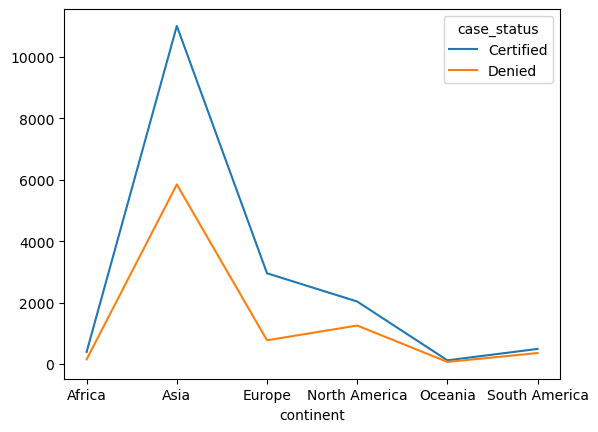

In [71]:
col1 = visa['case_status']
col2 = visa['continent']
r1 = pd.crosstab(col2,col1)
r1.plot()

<Axes: xlabel='continent'>

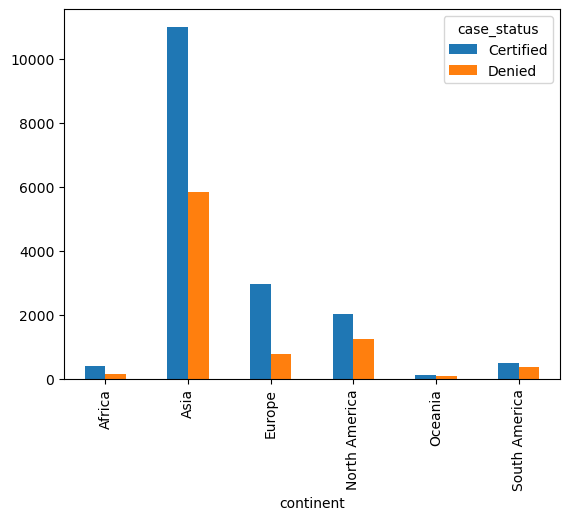

In [73]:
r1.plot(kind='bar')

<Axes: xlabel='continent'>

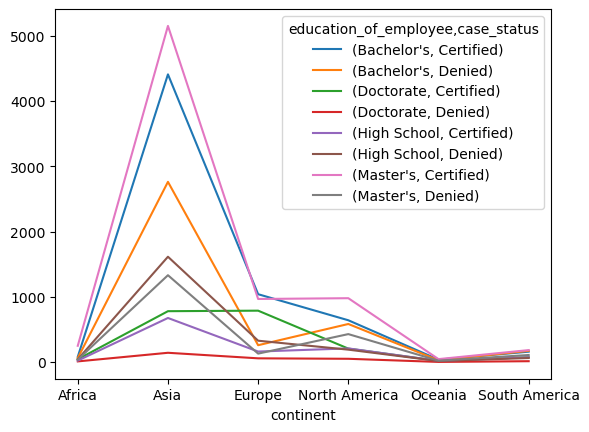

In [75]:
col1 = visa['case_status']
col2 = visa['continent']
col3 = visa['education_of_employee']
idx = col2
cols = [col3,col1]
r2 = pd.crosstab(idx,cols)
r2.plot()

<Axes: xlabel='continent'>

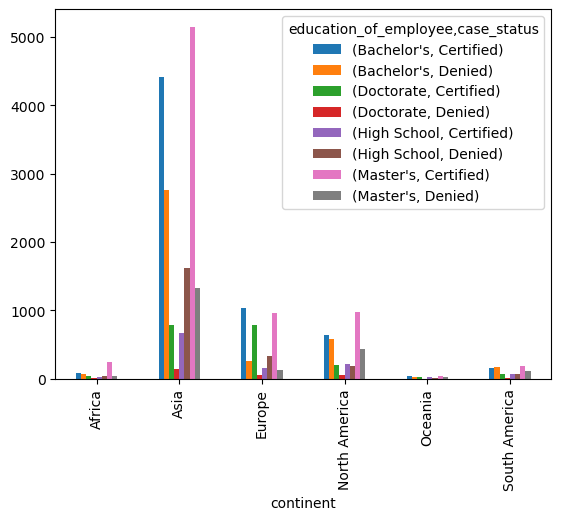

In [77]:
r2.plot(kind='bar')

<Axes: ylabel='Frequency'>

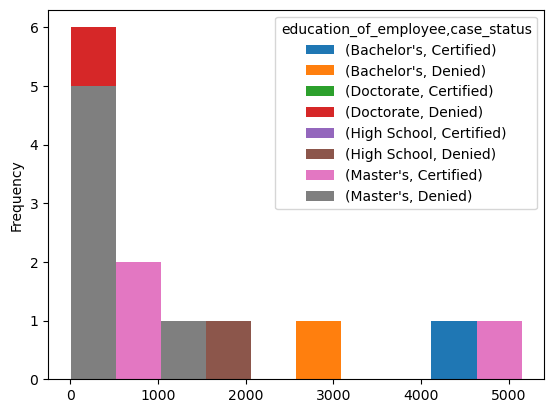

In [79]:
r2.plot(kind='hist')

<Axes: ylabel='Density'>

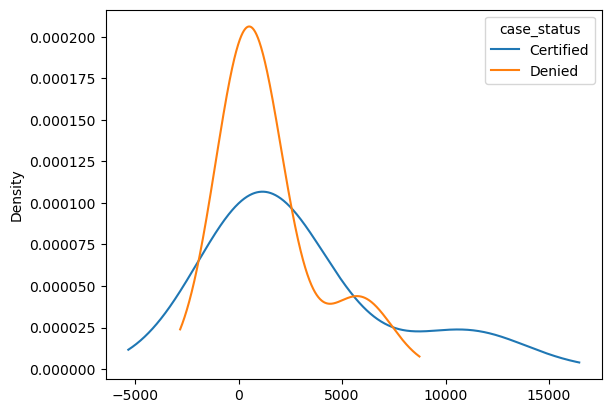

In [85]:
r1.plot(kind='kde')

<Axes: xlabel='continent'>

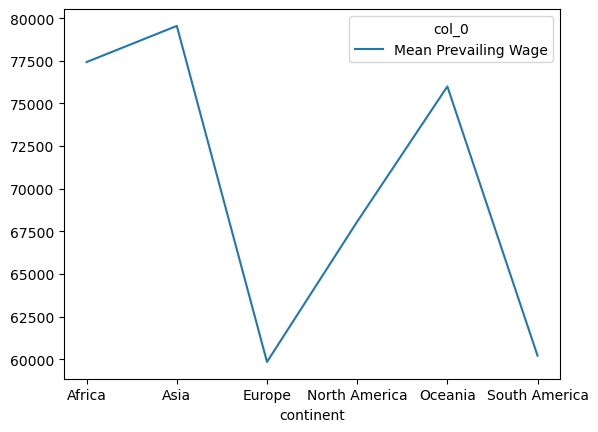

In [91]:
r3 = pd.crosstab(
    index=visa['continent'],
    columns='Mean Prevailing Wage',
    values=visa['prevailing_wage'],
    aggfunc='mean'
)

r3.plot()


In [93]:
visa.groupby('continent')['prevailing_wage'].mean()

continent
Africa           77425.923450
Asia             79543.021780
Europe           59842.925899
North America    68066.319257
Oceania          75994.276719
South America    60209.575314
Name: prevailing_wage, dtype: float64

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

visa = pd.read_csv('/Users/pranay/Naresh IT/Data Files/Visadataset.csv')

cat = visa.select_dtypes(include='object').columns
num = visa.select_dtypes(exclude='object').columns

**group by**

In [5]:
visa['prevailing_wage'].mean()

74455.81459209183

In [7]:
con = visa['continent']=='Asia'
visa[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [11]:
con = visa['continent']=='Asia'
visa[con]['prevailing_wage'].mean()

79543.02178043414

In [15]:
list(visa.groupby('continent'))

[('Africa',
           case_id continent education_of_employee has_job_experience  \
  4         EZYV05    Africa              Master's                  Y   
  18        EZYV19    Africa              Master's                  Y   
  74        EZYV75    Africa              Master's                  Y   
  194      EZYV195    Africa              Master's                  Y   
  242      EZYV243    Africa            Bachelor's                  N   
  ...          ...       ...                   ...                ...   
  25385  EZYV25386    Africa             Doctorate                  Y   
  25408  EZYV25409    Africa              Master's                  Y   
  25443  EZYV25444    Africa            Bachelor's                  N   
  25446  EZYV25447    Africa              Master's                  N   
  25474  EZYV25475    Africa             Doctorate                  N   
  
        requires_job_training  no_of_employees  yr_of_estab  \
  4                         N             1082

In [17]:
list(visa.groupby('continent'))[0]

('Africa',
          case_id continent education_of_employee has_job_experience  \
 4         EZYV05    Africa              Master's                  Y   
 18        EZYV19    Africa              Master's                  Y   
 74        EZYV75    Africa              Master's                  Y   
 194      EZYV195    Africa              Master's                  Y   
 242      EZYV243    Africa            Bachelor's                  N   
 ...          ...       ...                   ...                ...   
 25385  EZYV25386    Africa             Doctorate                  Y   
 25408  EZYV25409    Africa              Master's                  Y   
 25443  EZYV25444    Africa            Bachelor's                  N   
 25446  EZYV25447    Africa              Master's                  N   
 25474  EZYV25475    Africa             Doctorate                  N   
 
       requires_job_training  no_of_employees  yr_of_estab  \
 4                         N             1082         2005   

In [19]:
list(visa.groupby('continent'))[0][1]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified
18,EZYV19,Africa,Master's,Y,N,4743,2004,Midwest,150441.13,Year,Y,Certified
74,EZYV75,Africa,Master's,Y,N,3705,2001,South,47170.76,Year,Y,Certified
194,EZYV195,Africa,Master's,Y,N,2180,1992,Midwest,113637.40,Year,Y,Certified
242,EZYV243,Africa,Bachelor's,N,Y,2509,2003,West,51886.04,Year,Y,Denied
...,...,...,...,...,...,...,...,...,...,...,...,...
25385,EZYV25386,Africa,Doctorate,Y,N,2513,1975,West,76348.20,Year,Y,Certified
25408,EZYV25409,Africa,Master's,Y,Y,1671,1992,Midwest,55756.35,Year,Y,Certified
25443,EZYV25444,Africa,Bachelor's,N,N,72892,2007,Northeast,215.10,Hour,Y,Certified
25446,EZYV25447,Africa,Master's,N,Y,2024,1971,South,42353.45,Year,Y,Certified


In [21]:
list(visa.groupby('continent'))[1][1]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [23]:
list(visa.groupby('continent'))[2][1]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
9,EZYV10,Europe,Doctorate,Y,N,2251,1995,South,67514.76,Year,Y,Certified
16,EZYV17,Europe,Master's,Y,N,76638,1991,Midwest,3706.79,Year,Y,Certified
24,EZYV25,Europe,Doctorate,Y,N,241,1981,Midwest,71286.04,Year,Y,Certified
36,EZYV37,Europe,High School,Y,N,2520,1981,West,2490.12,Year,Y,Denied
37,EZYV38,Europe,Master's,Y,Y,44,1965,South,110817.26,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25435,EZYV25436,Europe,Bachelor's,N,N,1606,1998,South,126329.96,Year,Y,Certified
25448,EZYV25449,Europe,Doctorate,Y,N,4119,1971,West,86894.10,Year,Y,Certified
25460,EZYV25461,Europe,Master's,Y,Y,413,1997,West,8263.47,Year,Y,Certified
25462,EZYV25463,Europe,Bachelor's,N,Y,1715,2004,West,166032.62,Year,Y,Denied


In [25]:
list(visa.groupby('continent'))[1][1]['prevailing_wage'].mean()

79543.02178043414

In [27]:
visa.groupby('continent')['prevailing_wage'].mean()

continent
Africa           77425.923450
Asia             79543.021780
Europe           59842.925899
North America    68066.319257
Oceania          75994.276719
South America    60209.575314
Name: prevailing_wage, dtype: float64

In [31]:
visa.groupby('continent').size()

continent
Africa             551
Asia             16861
Europe            3732
North America     3292
Oceania            192
South America      852
dtype: int64

In [37]:
visa.groupby('continent').value_counts()

continent      case_id    education_of_employee  has_job_experience  requires_job_training  no_of_employees  yr_of_estab  region_of_employment  prevailing_wage  unit_of_wage  full_time_position  case_status
Africa         EZYV05     Master's               Y                   N                      1082             2005         South                 149907.3900      Year          Y                   Certified      1
               EZYV10041  Bachelor's             Y                   N                      1368             1871         South                 63626.2600       Year          Y                   Certified      1
               EZYV10048  High School            Y                   N                      474              1873         West                  101709.4200      Year          Y                   Denied         1
               EZYV10050  Bachelor's             N                   N                      875              1928         West                  58517.4800   

In [39]:
visa['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

**plt.scatter**

In [ ]:
# num vs num

# covariance

# correlation

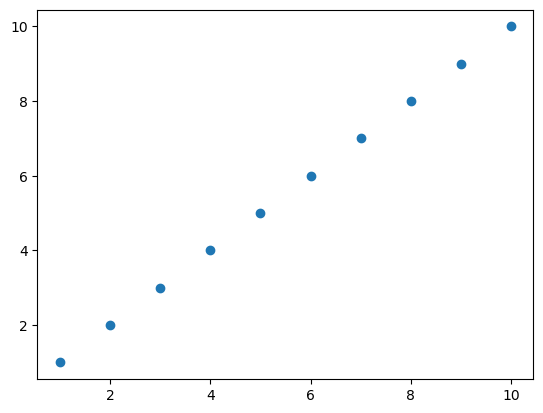

In [52]:
x = range(1,11)
y = range(1,11)

plt.scatter(x,y)
plt.show()

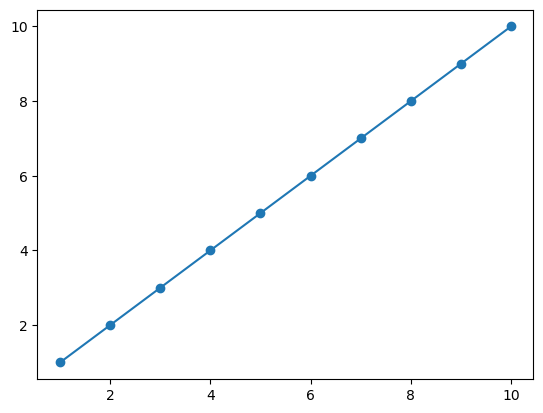

In [54]:
x = range(1,11)
y = range(1,11)

plt.scatter(x,y)
plt.plot(x,y)
plt.show()

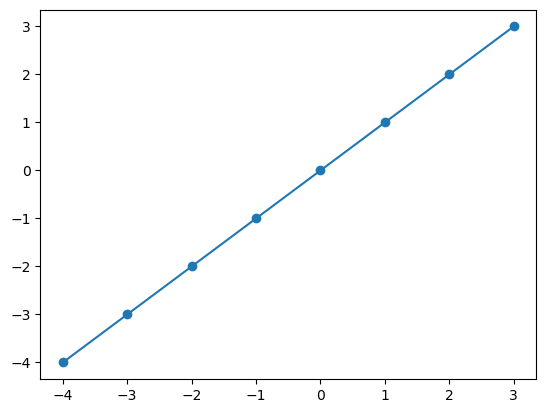

In [56]:
x = range(-4,4)
y = range(-4,4)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

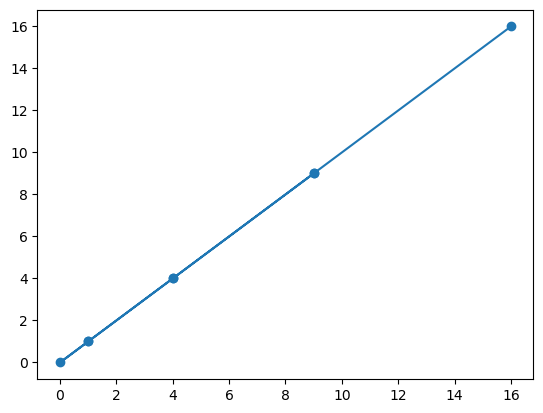

In [64]:
x = np.square(range(-4,4))
y = np.square(range(-4,4))

plt.scatter(x,y)
plt.plot(x,y)
plt.show()

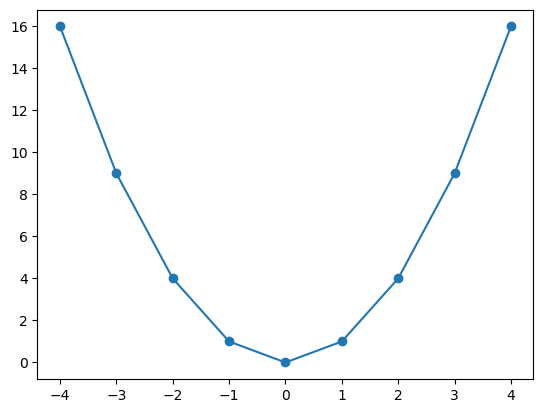

In [68]:
x = range(-4,5)
y = [i*i for i in x]

plt.scatter(x,y)
plt.plot(x,y)
plt.show()

In [70]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

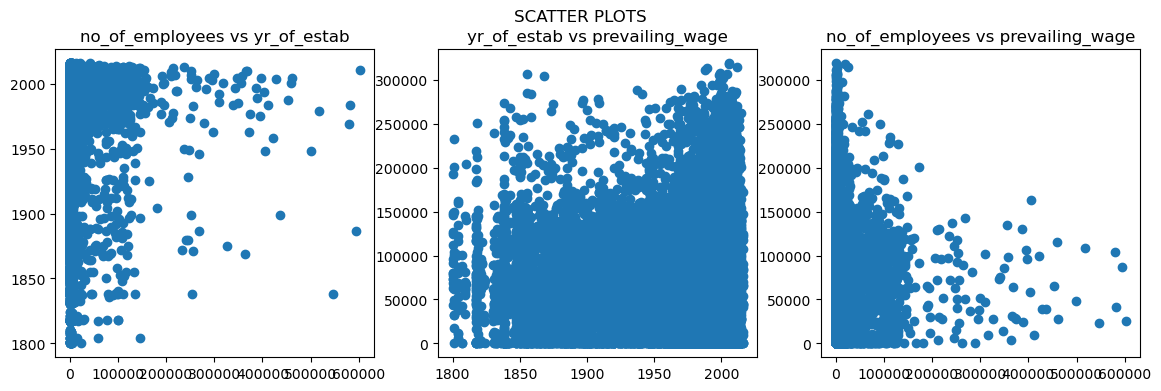

In [94]:
col1 = visa['no_of_employees']
col2 = visa['yr_of_estab']
col3 = visa['prevailing_wage']

plt.figure(figsize=(14,4))
plt.suptitle('SCATTER PLOTS')
plt.subplot(1,3,1).scatter(col1,col2)
plt.title('no_of_employees vs yr_of_estab')
plt.subplot(1,3,2).scatter(col2,col3)
plt.title('yr_of_estab vs prevailing_wage')
plt.subplot(1,3,3).scatter(col1,col3)
plt.title('no_of_employees vs prevailing_wage')
plt.show()

**correlation**

In [103]:
visa.corr() # categorical columns will raise error as it performs operation only on numeric columns

ValueError: could not convert string to float: 'EZYV01'

In [101]:
visa.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [105]:
visa.cov(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,5.233996e+08,-17224.155003,-1.150624e+07
yr_of_estab,-1.722416e+04,1794.956681,2.761653e+04
prevailing_wage,-1.150624e+07,27616.530171,2.789524e+09


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

wine = pd.read_csv('/Users/pranay/Naresh IT/Data Files/winequality_red.csv')

cat = visa.select_dtypes(include='object').columns
num = visa.select_dtypes(exclude='object').columns

In [109]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [115]:
wine.corr() # as this dataset have only numeric cols so need to explicitly declared numeric_only = True in function

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [117]:
wine.cov()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,3.031416,-0.079851,0.227820,0.281756,0.007679,-2.800921,-6.482346,0.002195,-0.183586,0.054010,-0.114421,0.174424
volatile acidity,-0.079851,0.032062,-0.019272,0.000484,0.000517,-0.019674,0.450426,0.000007,0.006495,-0.007921,-0.038600,-0.056476
citric acid,0.227820,-0.019272,0.037947,0.039434,0.001869,-0.124252,0.227697,0.000134,-0.016298,0.010328,0.022815,0.035612
residual sugar,0.281756,0.000484,0.039434,1.987897,0.003690,2.758611,9.416441,0.000945,-0.018644,0.001321,0.063219,0.015635
chlorides,0.007679,0.000517,0.001869,0.003690,0.002215,0.002738,0.073387,0.000018,-0.001926,0.002962,-0.011092,-0.004900
free sulfur dioxide,-2.800921,-0.019674,-0.124252,2.758611,0.002738,109.414884,229.737521,-0.000433,0.113653,0.091592,-0.773698,-0.427907
total sulfur dioxide,-6.482346,0.450426,0.227697,9.416441,0.073387,229.737521,1082.102373,0.004425,-0.337699,0.239471,-7.209298,-4.917237
density,0.002195,0.000007,0.000134,0.000945,0.000018,-0.000433,0.004425,0.000004,-0.000100,0.000048,-0.000998,-0.000267
pH,-0.183586,0.006495,-0.016298,-0.018644,-0.001926,0.113653,-0.337699,-0.000100,0.023835,-0.005146,0.033832,-0.007198
sulphates,0.054010,-0.007921,0.010328,0.001321,0.002962,0.091592,0.239471,0.000048,-0.005146,0.028733,0.016907,0.034413


**heatmap**

- any matrix we can represent with color

- color bar

    - it will divide the value in intervals

    - one intervals will give one color


<Axes: >

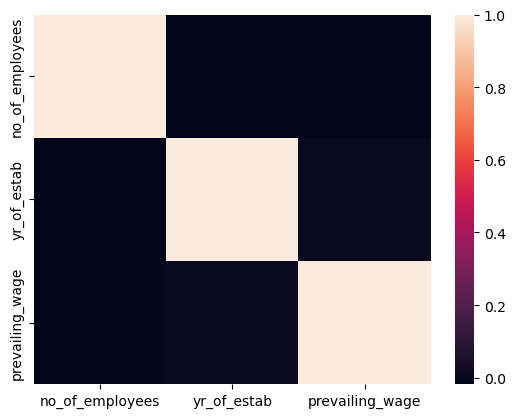

In [120]:
corr = visa.corr(numeric_only=True)
sns.heatmap(data=corr)

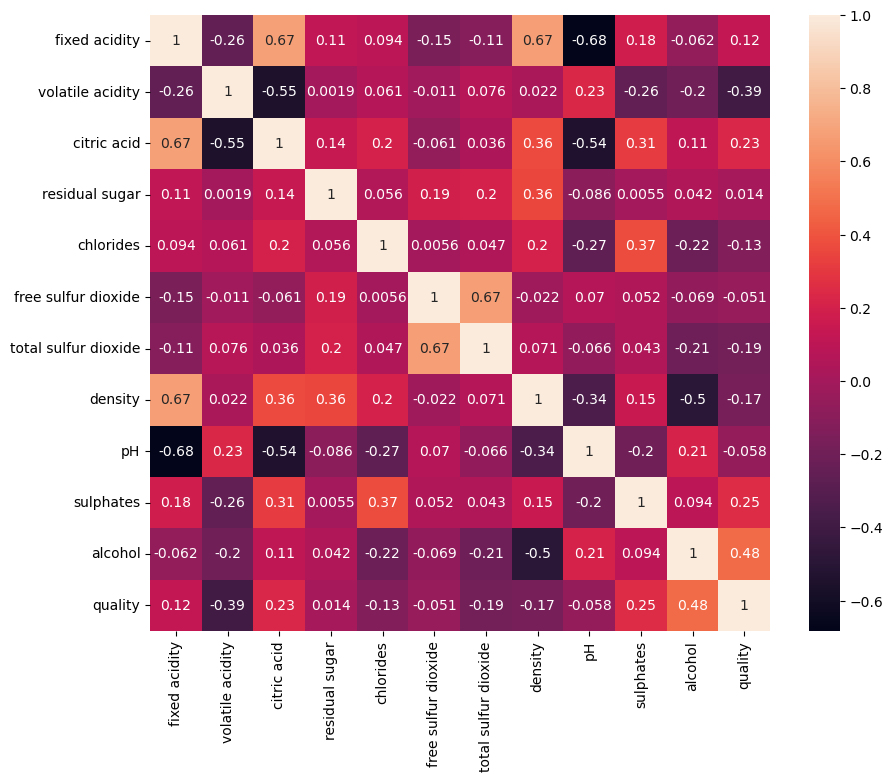

In [132]:
plt.figure(figsize=(10,8))
sns.heatmap(wine.corr(),annot=True)
plt.show()

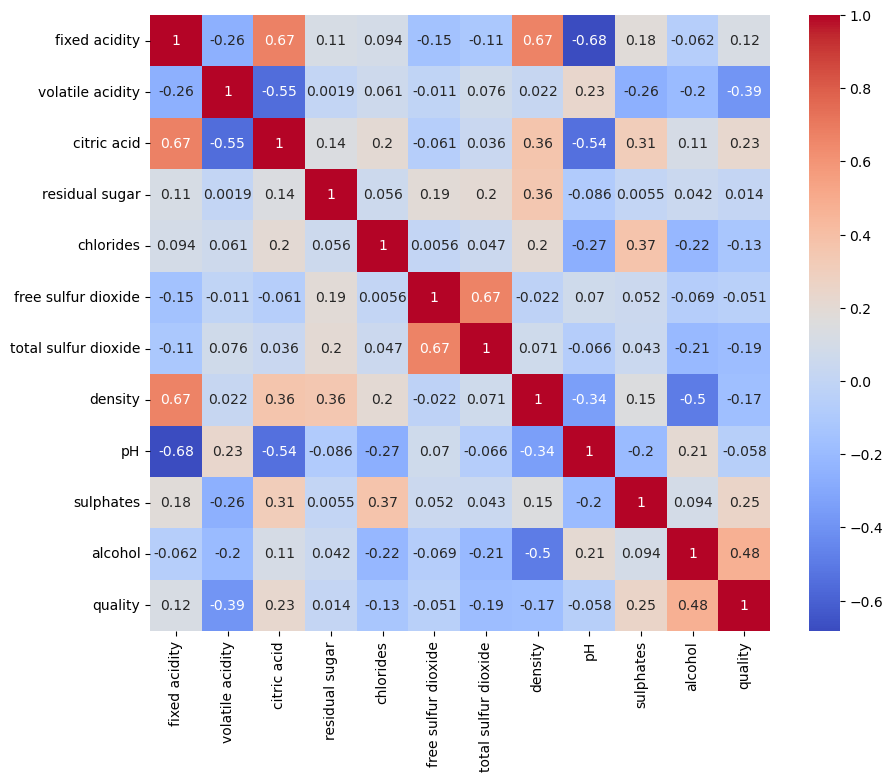

In [136]:
corr = wine.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [144]:
wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

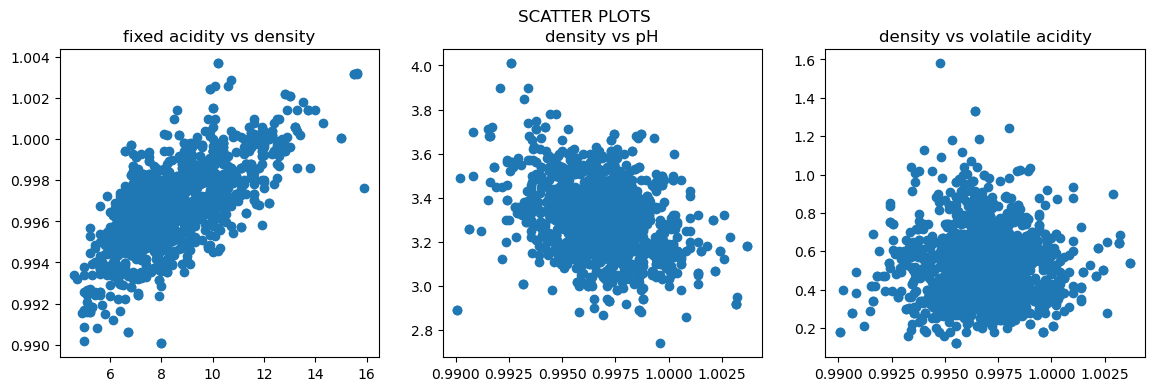

In [152]:
col1 = wine['fixed acidity']
col2 = wine['density']
col3 = wine['pH']
col4 = wine['volatile acidity']
plt.figure(figsize=(14,4))
plt.suptitle('SCATTER PLOTS')
plt.subplot(1,3,1).scatter(col1,col2)
plt.title('fixed acidity vs density')
plt.subplot(1,3,2).scatter(col2,col3)
plt.title('density vs pH')
# plt.subplot(1,3,3).scatter(col1,col3)
# plt.title('fixed acidity vs pH')
plt.subplot(1,3,3).scatter(col2,col4)
plt.title('density vs volatile acidity')
plt.show()